In [1]:
# imports

import os, re, json, pickle, torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, accuracy_score

# model 2 - bert
import torch
from torch.utils.data import Dataset, DataLoader # Added Dataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import f1_score # Added f1_score
from tqdm import tqdm

# model 3 - hybrid 
import optuna

# model 4 - lstm 
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from sklearn.metrics import f1_score

# Suppress minor warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

### data crawl
* preprocessing included in moviedataorchestrator 
    * clean currency
    * normalize rating 

In [2]:
class MovieWorkflowManager:
    def __init__(self):
        self.base_path = os.getcwd() 
        self.folders = {
            "audience-reviews":      {"type": "audience", "platform": "rt"},
            "critic-reviews-rt":        {"type": "critic",   "platform": "rt"},
            "audience-reviews-imdb": {"type": "audience", "platform": "imdb"},
            # "critic-reviews-metacritic": {"type": "critic",   "platform": "metacritic"}
        }
        self.stats = {"scraped_files": 0, "dropped_no_finance": 0, "final_movies": 0}

    def clean_val(self, v):
        if pd.isna(v) or v == "N/A": return np.nan
        s = re.sub(r'[^\d.]', '', str(v))
        return float(s) if s else np.nan

    def slugify(self, filename):
        name = os.path.splitext(filename)[0].lower()
        for term in ["reviews", "imdb", "rt", "roger", "ebert", "metadata", "audience", "critic"]:
            name = name.replace(term, "")
        return name.strip("_")

    def load_master_metadata(self):
        meta_list = []
        for folder in self.folders.keys():
            path = os.path.join(self.base_path, folder)
            if not os.path.exists(path): continue
            meta_files = [f for f in os.listdir(path) if "metadata" in f.lower() and f.endswith(".csv")]
            for mf in meta_files:
                temp_df = pd.read_csv(os.path.join(path, mf))
                temp_df.columns = [c.lower().strip() for c in temp_df.columns]
                # Try to find a 'movie_key' or 'title' column
                key_col = 'movie_key' if 'movie_key' in temp_df.columns else temp_df.columns[0]
                temp_df['movie_key_clean'] = temp_df[key_col].apply(self.slugify)
                meta_list.append(temp_df[['movie_key_clean', 'budget', 'gross_us', 'year']])
        
        master = pd.concat(meta_list).drop_duplicates(subset=['movie_key_clean'])
        master['budget'] = master['budget'].apply(self.clean_val)
        master['gross'] = master['gross_us'].apply(self.clean_val)
        return master.dropna(subset=['budget', 'gross']).set_index('movie_key_clean')
    
    def standardize_score(self, val, platform):
        if pd.isna(val) or val == "": return np.nan
        
        # 1. Clean the string
        # Handles "4/5", "8.5/10", "80%"
        val_str = str(val).split('/')[0].replace('%', '').strip()
        try:
            score = float(val_str)
        except ValueError:
            return np.nan

        # 2. Apply Platform-Specific Logic
        if platform == "imdb":
            # IMDB is almost always 0-10
            return score / 10.0
        
        if platform == "rt":
            # RT is tricky: Audience is 0-5, Critics are often 0-10 or 0-100
            if score > 10:   # Likely 0-100%
                return score / 100.0
            if score <= 5:   # Likely 0-5 stars
                return score / 5.0
            return score / 10.0 # Likely 0-10
            
        return score # Fallback

    def run_full_extraction(self):
            master_meta = self.load_master_metadata()
            all_data = []

            for folder, info in self.folders.items():
                path = os.path.join(self.base_path, folder)
                if not os.path.exists(path): continue
                files = [f for f in os.listdir(path) if f.endswith(".csv") and "metadata" not in f.lower()]
                
                for f in files:
                    self.stats["scraped_files"] += 1
                    key = self.slugify(f)
                    
                    if key in master_meta.index:
                        m = master_meta.loc[key]
                        rdf = pd.read_csv(os.path.join(path, f))
                        rdf.columns = [c.lower().strip() for c in rdf.columns]
                        
                        # --- IMPROVED SCORE DETECTION & STANDARDIZATION ---
                        score_col = None
                        for col in ['user_rating', 'score', 'rating', 'stars', 'user rating']:
                            if col in rdf.columns:
                                score_col = col
                                break
                        
                        if score_col:
                            # Apply the standardization logic here
                            rdf['user_rating'] = rdf[score_col].apply(
                                lambda x: self.standardize_score(x, info['platform'])
                            )
                        else:
                            rdf['user_rating'] = np.nan
                        
                        # Fill other metadata
                        rdf['movie_title'] = key
                        rdf['budget'] = m['budget']
                        rdf['gross'] = m['gross']
                        rdf['year'] = m['year']
                        rdf['is_critic'] = 1 if info['type'] == "critic" else 0
                        all_data.append(rdf)
                    else:
                        self.stats["dropped_no_finance"] += 1
            
            full_df = pd.concat(all_data, ignore_index=True)
            # Calculate label (3x ROI)
            full_df['label'] = (full_df['gross'] / full_df['budget'] >= 3.0).astype(int)
            self.stats["final_movies"] = full_df['movie_title'].nunique()
            return full_df
    
    def run_eda_visuals(self, df):
        """Step 3: Required EDA and Visualization"""
        print("\n" + "="*30)
        print(" EXPLORATORY DATA ANALYSIS ")
        print("="*30)
        
        # 1. Survival Table
        print(f"Total Review Files Scraped: {self.stats['scraped_files']}")
        print(f"Files dropped (no budget info): {self.stats['dropped_no_finance']}")
        print(f"Final Unique Movies in Study: {self.stats['final_movies']}")
        
        # 2. Survival Bar Chart
        plt.figure(figsize=(8, 4))
        sns.barplot(x=['Scraped', 'Valid (Financials)'], 
                    y=[self.stats['scraped_files'], self.stats['final_movies']], palette="mako")
        plt.title("Workflow Step: Data Survival Comparison")
        plt.ylabel("Count of Movies")
        plt.show()

        # --- 3. FIX FOR AUDIENCE VS CRITIC PLOT ---
        # Ensure we only look at rows with a rating
        temp_df = df.dropna(subset=['user_rating']).copy()
        
        # Group and unstack: Column 0 = Audience, Column 1 = Critic
        corr_data = temp_df.groupby(['movie_title', 'is_critic'])['user_rating'].mean().unstack()

        # We must drop rows that don't have BOTH an audience and a critic score
        # If we don't do this, the plot will be empty or show an error
        if corr_data.shape[1] >= 2:
            corr_plot_data = corr_data.dropna(subset=[0, 1])
            
            if not corr_plot_data.empty:
                plt.figure(figsize=(7, 7))
                sns.regplot(x=corr_plot_data[0], y=corr_plot_data[1], 
                            scatter_kws={'alpha':0.5, 'color':'teal'}, 
                            line_kws={'color':'red'})
                plt.xlabel("Average Audience Rating")
                plt.ylabel("Average Critic Rating")
                plt.title("Psychological Alignment: Audience vs. Critic")
                plt.grid(True, alpha=0.3)
                plt.show()
                
                r_val = corr_plot_data[0].corr(corr_plot_data[1])
                print(f"Sentiment Correlation Coefficient: {r_val:.2f}")
            else:
                print("Warning: No movies have both Audience AND Critic ratings. Check your data folders.")
        else:
            print(f"Warning: Only one 'is_critic' type found. Available types: {corr_data.columns.tolist()}")


    def generate_trials(self, df):
        # We need to keep rows even if user_rating is NaN to maximize text data for Trial B
        clean_df = df.dropna(subset=['review_text']).copy()
        trial_a = clean_df.copy()
        
        trial_b = clean_df.groupby('movie_title').agg({
            'review_text': lambda x: " [SEP] ".join(str(i) for i in x.fillna("")[:10]),
            'budget': 'first',
            'year': 'first',
            'label': 'first',
            'user_rating': 'mean',
            'is_critic': 'mean'
        }).reset_index()
        
        return trial_a, trial_b

### the architecture (the classes)

In [3]:
class MovieDataset(Dataset):
    def __init__(self, texts, numeric, labels, tok):
        self.texts = texts
        self.numeric = torch.tensor(numeric, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tok = tok
    
    def __len__(self): return len(self.labels)
    
    def __getitem__(self, i):
        e = self.tok(str(self.texts[i]), max_length=128, truncation=True, padding="max_length", return_tensors="pt")
        return {
            "ids": e["input_ids"].squeeze(0), 
            "mask": e["attention_mask"].squeeze(0), 
            "num": self.numeric[i], 
            "lab": self.labels[i]
        }

class MovieClassifier(nn.Module):
    def __init__(self, n_dim, hidden_dim, dropout_prob):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        for n, p in self.bert.named_parameters():
            if "encoder.layer.11" not in n: p.requires_grad = False

        self.num_bnch = nn.Sequential(
            nn.Linear(n_dim, 64), 
            nn.ReLU(),
            nn.Dropout(dropout_prob)
        )

        self.fusion = nn.Sequential(
            nn.Linear(768 + 64, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, ids, mask, num):
        t_f = self.bert(ids, mask).last_hidden_state[:, 0, :]
        n_f = self.num_bnch(num)
        return self.fusion(torch.cat([t_f, n_f], dim=1)).squeeze(1)

### evaluate trial A and B 

In [4]:
def compare_trials_initially(t_a, t_b):
    results = {}
    
    # UPDATE: Changed 'score' to 'user_rating' to match your data
    feats = ['user_rating'] 
    
    for name, df in [("Trial A (Individual)", t_a), ("Trial B (Collective)", t_b)]:
        # 1. Clean data for this trial
        # We also check if the columns actually exist before dropping
        existing_feats = [f for f in feats if f in df.columns]
        temp_df = df.dropna(subset=existing_feats + ['label'])
        
        # SAFETY CHECK: Print how many rows are left
        print(f"Checking {name}: {len(temp_df)} rows found with valid features.")
        
        if len(temp_df) == 0:
            print(f"⚠️ Skipping {name} because it has 0 rows. Check column names!")
            continue

        X = temp_df[existing_feats]
        y = temp_df['label']
        
        # 2. Split (Ensuring the same movie isn't in both Train and Test)
        gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        
        try:
            train_idx, test_idx = next(gss.split(X, y, groups=temp_df['movie_title']))
            
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            # 3. Train a quick Random Forest (Method 1 Baseline)
            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)
            
            # 4. Score it
            preds = rf.predict(X_test)
            acc = accuracy_score(y_test, preds)
            f1 = f1_score(y_test, preds, average='weighted')
            
            results[name] = {"Accuracy": acc, "F1-Score": f1}
            print(f"--- {name} Results ---")
            print(f"Accuracy: {acc:.3f} | F1-Score: {f1:.3f}\n")
        except Exception as e:
            print(f"Error processing {name}: {e}")
        
    winner = max(results, key=lambda x: results[x]['F1-Score'])
    print(f"The more accurate data structure is: {winner}")
    return winner

# RUN THE COMPARISON



 EXPLORATORY DATA ANALYSIS 
Total Review Files Scraped: 714
Files dropped (no budget info): 158
Final Unique Movies in Study: 199


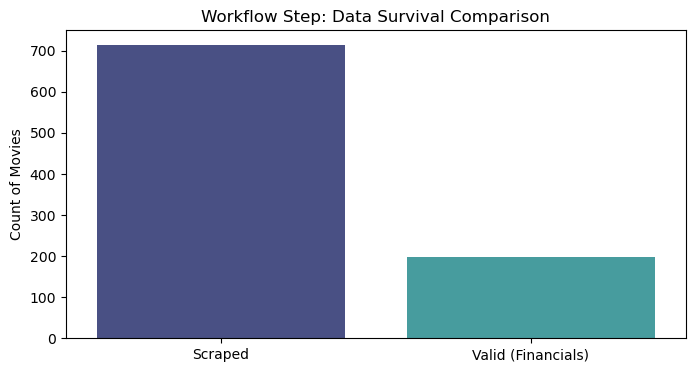

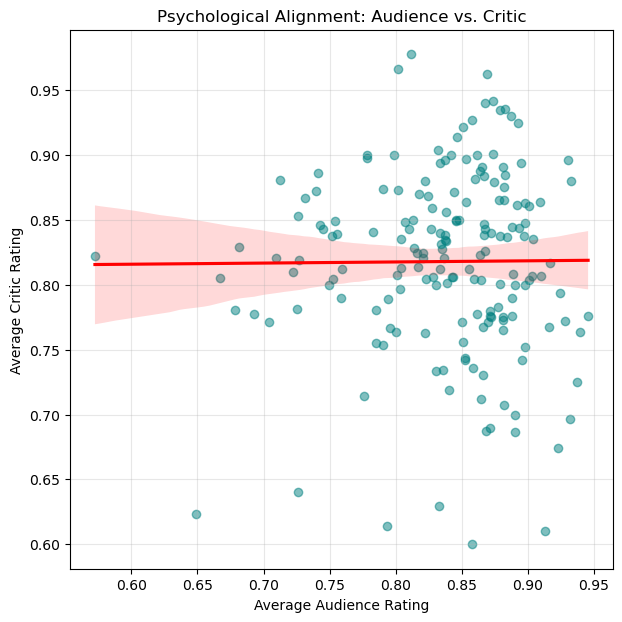

Sentiment Correlation Coefficient: 0.01
Checking Trial A (Individual): 22031 rows found with valid features.
--- Trial A (Individual) Results ---
Accuracy: 0.627 | F1-Score: 0.484

Checking Trial B (Collective): 199 rows found with valid features.
--- Trial B (Collective) Results ---
Accuracy: 0.567 | F1-Score: 0.572

The more accurate data structure is: Trial B (Collective)


In [5]:
# execution 

# intialize and extract 
manager = MovieWorkflowManager()
full_dataset = manager.run_full_extraction()

# run eda 
manager.run_eda_visuals(full_dataset)

# generate trials
trial_a, trial_b = manager.generate_trials(full_dataset)
winning_trial_name = compare_trials_initially(trial_a, trial_b)

In [6]:
# Select Trial B for training volume
df_final = trial_b

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df_final, groups=df_final['movie_title']))
train_df, test_df = df_final.iloc[train_idx].copy(), df_final.iloc[test_idx].copy()

numeric_feats = ['user_rating', 'budget']

In [7]:
# ECONOMIC CONFUSION MATRIX
def plot_economic_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    # Manual check for binary cases
    if cm.shape == (1,1): # Handles edge cases where only one label is predicted
        print("Warning: Only one class predicted, Confusion Matrix plot skipped.")
        return
        
    labels = [
        ["True Negative\n(Avoided Disaster)", "False Positive\n(The Money Pit)"],
        ["False Negative\n(Sleeper Hit)", "True Positive\n(The Blockbuster)"]
    ]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Predicted Flop", "Predicted Hit"],
                yticklabels=["Actual Flop", "Actual Hit"])
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j+0.5, i+0.7, labels[i][j], ha='center', va='center', fontsize=10, color='darkred')
            
    plt.title(title)
    plt.show()

--- RUNNING METHOD 1: NUMERIC BASELINE ---
Method 1 (Numeric Only) F1-Score: 0.630



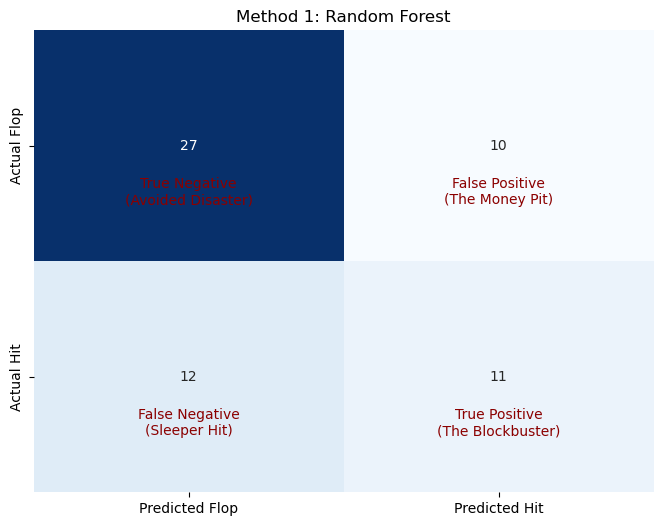

In [8]:
# METHOD 1: RANDOM FOREST (Numeric Baseline Only)
print("--- RUNNING METHOD 1: NUMERIC BASELINE ---")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_num = scaler.transform(test_df[numeric_feats].fillna(0))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_num, train_df['label'])

m1_preds = rf_model.predict(X_test_num)
m1_f1 = f1_score(test_df['label'], m1_preds, average='weighted')

print(f"Method 1 (Numeric Only) F1-Score: {m1_f1:.3f}\n")
plot_economic_matrix(test_df['label'], m1_preds, "Method 1: Random Forest")


Using device for BERT: mps
--- RUNNING METHOD 2: BERT QUALITATIVE BASELINE ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- STARTING TRAINING ---


Epoch 1: 100%|██████████| 18/18 [00:17<00:00,  1.01it/s]


Epoch 1 average loss: 0.7092


Epoch 2: 100%|██████████| 18/18 [00:16<00:00,  1.12it/s]


Epoch 2 average loss: 0.6730
--- EVALUATING ---


Testing: 100%|██████████| 8/8 [00:04<00:00,  1.71it/s]


Method 2 (BERT Only) F1-Score: 0.463


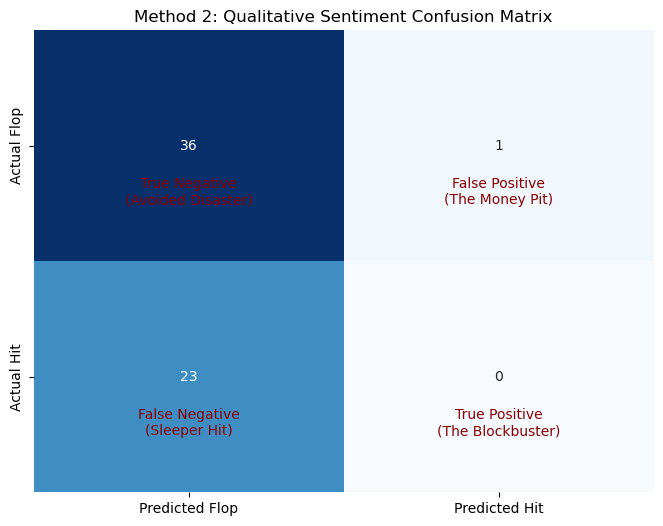

In [9]:
# METHOD 2: BERT ONLY (Qualitative Baseline Only)

# 1. Set the device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): # For Apple Silicon Macs
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device for BERT: {device}")

class SimpleTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        encoding = self.tokenizer(self.texts[i], truncation=True, padding='max_length', max_length=256, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }
    
print("--- RUNNING METHOD 2: BERT QUALITATIVE BASELINE ---")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
m2_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

# freeze all layers except top 2 
for name, param in m2_model.bert.named_parameters():
    if "encoder.layer.11" not in name and "encoder.layer.10" not in name:
        param.requires_grad = False

# Prepare DataLoaders
train_ds = SimpleTextDataset(train_df['review_text'].tolist(), train_df['label'].tolist(), tokenizer)
test_ds = SimpleTextDataset(test_df['review_text'].tolist(), test_df['label'].tolist(), tokenizer)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8)

# Optimizer only passing parameters that require gradients
optimizer = AdamW(filter(lambda p: p.requires_grad, m2_model.parameters()), lr=2e-5)

# Training Loop
print("--- STARTING TRAINING ---")
m2_model.train()
for epoch in range(2): 
    total_loss = 0
    # Added tqdm for a progress bar so you know it's not frozen
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = m2_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} average loss: {total_loss/len(train_loader):.4f}")

print("--- EVALUATING ---")
m2_model.eval()
m2_preds = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = m2_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        m2_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

m2_f1 = f1_score(test_df['label'], m2_preds, average='weighted')
print(f"\nMethod 2 (BERT Only) F1-Score: {m2_f1:.3f}")
plot_economic_matrix(test_df['label'], m2_preds, "Method 2: Qualitative Sentiment Confusion Matrix")

In [13]:
# METHOD 3: TRAINING THE HYBRID

# hyperparameter tuning 
print("Running Hyperparameter tuning:")

def objective(trial, train_df, test_df, numeric_feats):
    lr = trial.suggest_float("lr", 0.0001, 0.001, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    dropout_prob = trial.suggest_float("dropout", 0.1, 0.4)
    batch_size = trial.suggest_categorical("batch_size", [8, 16])

    scaler = StandardScaler()
    X_tr_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
    X_te_num = scaler.transform(test_df[numeric_feats].fillna(0))
    
    tok = BertTokenizer.from_pretrained("bert-base-uncased")
    train_ldr = DataLoader(MovieDataset(train_df['review_text'].tolist(), X_tr_num, train_df['label'].tolist(), tok), 
                           batch_size=batch_size, shuffle=True)
    test_ldr = DataLoader(MovieDataset(test_df['review_text'].tolist(), X_te_num, test_df['label'].tolist(), tok), 
                          batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # NOTE: Changed this to 'MovieClassifier' to match your class name
    model = MovieClassifier(len(numeric_feats), hidden_dim, dropout_prob).to(device)
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    model.train()
    for epoch in range(2): 
        for b in train_ldr:
            optimizer.zero_grad()
            out = model(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
            loss = criterion(out, b["lab"].to(device))
            loss.backward()
            optimizer.step()

    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for b in test_ldr:
            logits = model(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
            p = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
            preds.extend(p)
            actuals.extend(b["lab"].numpy())

    return f1_score(actuals, preds, average='weighted')

def run_hyperparameter_tuning(train_df, test_df, numeric_feats, n_trials=10):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, train_df, test_df, numeric_feats), n_trials=n_trials)
    return study.best_params

print("RUNNING METHOD 3: HYBRID")

numeric_feats = ['user_rating', 'budget']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = BertTokenizer.from_pretrained("bert-base-uncased")

best_params = run_hyperparameter_tuning(train_df, test_df, numeric_feats, n_trials=5)
# Extract the best settings found by Optuna
best_lr = best_params['lr']
best_batch = best_params['batch_size']
best_hidden_dim = best_params['hidden_dim']

# Scaling numeric data
X_tr_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_te_num = scaler.transform(test_df[numeric_feats].fillna(0))

# Preparing DataLoaders using your MovieDataset
train_ldr = DataLoader(
    MovieDataset(train_df['review_text'].tolist(), X_tr_num, train_df['label'].tolist(), tok), 
    batch_size=best_batch, 
    shuffle=True
)
test_ldr = DataLoader(
    MovieDataset(test_df['review_text'].tolist(), X_te_num, test_df['label'].tolist(), tok), 
    batch_size=best_batch
)

# Initializing your MovieClassifier
model_hybrid = MovieClassifier(
    n_dim=len(numeric_feats), 
    hidden_dim=best_params['hidden_dim'], 
    dropout_prob=best_params['dropout']
).to(device)
opt = AdamW(filter(lambda p: p.requires_grad, model_hybrid.parameters()), lr=best_lr)
crit = nn.BCEWithLogitsLoss()

# Training loop
model_hybrid.train()
for ep in range(3):
    total_loss = 0
    for b in train_ldr:
        opt.zero_grad()
        out = model_hybrid(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        loss = crit(out, b["lab"].to(device))
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {ep+1} | Loss: {total_loss/len(train_ldr):.4f}")

# Evaluation
model_hybrid.eval()
m3_probs = []
with torch.no_grad():
    for b in test_ldr:
        logits = model_hybrid(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        m3_probs.extend(torch.sigmoid(logits).cpu().numpy())

m3_preds = (np.array(m3_probs) >= 0.5).astype(int)
m3_f1 = f1_score(test_df['label'], m3_preds, average='weighted')
print(f"Method 3 (Hybrid) F1-Score with Optimized Params: {m3_f1:.3f}")

Running Hyperparameter tuning:
RUNNING METHOD 3: HYBRID


[I 2026-03-10 23:01:39,102] A new study created in memory with name: no-name-499c232e-5777-4480-9e50-85c66e01d75b
[I 2026-03-10 23:02:17,628] Trial 0 finished with value: 0.470446735395189 and parameters: {'lr': 0.00012377662097414567, 'hidden_dim': 512, 'dropout': 0.1603834496307183, 'batch_size': 16}. Best is trial 0 with value: 0.470446735395189.
[W 2026-03-10 23:02:37,627] Trial 1 failed with parameters: {'lr': 0.00026596836506104666, 'hidden_dim': 512, 'dropout': 0.20919744583109065, 'batch_size': 8} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/r3/stfjytn503v31lz63tk6sw_00000gn/T/ipykernel_87023/3751486712.py", line 52, in <lambda>
    study.optimize(lambda trial: objective(trial, train_df, test_df, numeric_feats), n_trials=n_trials)
               

KeyboardInterrupt: 

--- RUNNING METHOD 4: BIDIRECTIONAL LSTM ---
Finding optimal hyperparameters...
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5063
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5084
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5025
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.5209
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.4467
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.4365
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5063
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5197
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5448
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.4485
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.4810
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.5504
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5823
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5323
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.4952
Testing: LR

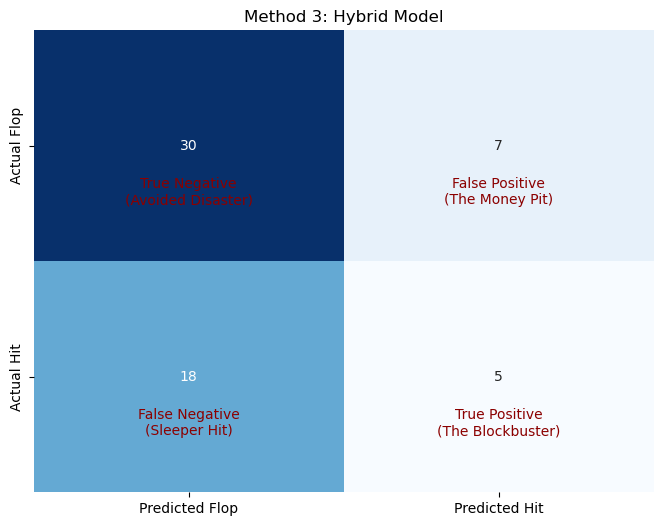

In [ ]:
# 1. SIMPLE VOCABULARY BUILDER

# To use an LSTM, we must turn words into integers manually.
def build_vocab(texts, max_vocab=10000):
    words = " ".join(texts).lower().split()
    count = Counter(words)
    # Filter for most common words
    vocab = {word: i+2 for i, (word, _) in enumerate(count.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

def text_to_indices(text, vocab):
    return [vocab.get(word.lower(), 1) for word in str(text).split()]

# hyperparameter tuner
def tune_lstm(train_indices, train_labels, test_indices, test_labels, vocab, device):
    lrs = [0.001, 0.0005, 0.0001]
    hiddens = [64, 128, 256]
    dropouts = [0.2, 0.5]
    embed_dims = [100, 200, 300]
    
    best_f1 = 0
    best_params = {}

    # Pre-pad data
    X_train = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    y_train = torch.tensor(train_labels.values, dtype=torch.float32).to(device)
    X_test = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    
    for lr in lrs:
        for hd in hiddens:
            for dr in dropouts:
                for ed in embed_dims:
                    print(f"Testing: LR={lr}, Hidden={hd}, Dropout={dr}")
                    model = MovieLSTM(len(vocab), ed, hd, dr).to(device) 
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                    criterion = nn.BCEWithLogitsLoss()
                    
                    model.train()
                    for epoch in range(5):
                        optimizer.zero_grad()
                        out = model(X_train)
                        loss = criterion(out, y_train)
                        loss.backward()
                        optimizer.step()
                    
                    model.eval()
                    with torch.no_grad():
                        logits = model(X_test)
                        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                        score = f1_score(test_labels, preds, average='weighted')
                    
                    print(f"Result F1: {score:.4f}")
                    if score > best_f1:
                        best_f1 = score
                        best_params = {'lr': lr, 'hidden': hd, 'dropout': dr, 'embed': ed} 
    
    return best_params

# 2. LSTM ARCHITECTURE (Sequential Memory Model)
class MovieLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout_prob=0.3):
        super(MovieLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Bidirectional=True mimics reading the review forward and backward
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        # 2 * hidden_dim because it is bidirectional
        self.dropout = nn.Dropout(dropout_prob) 
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, x):
        embedded = self.embedding(x)
        # We only take the final hidden state (the "memory") to make the prediction
        _, (hidden, _) = self.lstm(embedded)
        # Concatenate the final forward and backward hidden states
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden_cat = self.dropout(hidden_cat) 
        return self.fc(hidden_cat).squeeze(1)

# 3. PREPARATION & TRAINING
print("--- RUNNING METHOD 4: BIDIRECTIONAL LSTM ---")

# Use df_final (your winning trial)
vocab = build_vocab(train_df['review_text'])
train_indices = [torch.tensor(text_to_indices(t, vocab)) for t in train_df['review_text']]
test_indices = [torch.tensor(text_to_indices(t, vocab)) for t in test_df['review_text']]

# run tuner 
print("Finding optimal hyperparameters...")
best_configs = tune_lstm(train_indices, train_df['label'], test_indices, test_df['label'], vocab, device)

# data prep
X_train_lstm = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512]
X_test_lstm = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512]
y_train_lstm = torch.tensor(train_df['label'].values, dtype=torch.float32)

# final training 
print(f"Training final LSTM with: {best_configs}")
lstm_model = MovieLSTM(len(vocab), 128, best_configs['hidden'], best_configs['dropout']).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=best_configs['lr'])
criterion = nn.BCEWithLogitsLoss()

# Training Loop
lstm_model.train()
for epoch in range(5): 
    optimizer.zero_grad()
    outputs = lstm_model(X_train_lstm.to(device))
    loss = criterion(outputs, y_train_lstm.to(device))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
    optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# 4. EVALUATION
lstm_model.eval()
with torch.no_grad():
    m4_logits = lstm_model(X_test_lstm.to(device))
    m4_preds = (torch.sigmoid(m4_logits) >= 0.5).int().cpu().numpy()

m4_f1 = f1_score(test_df['label'], m4_preds, average='weighted')
print(f"\nMethod 4 (LSTM) F1-Score: {m4_f1:.3f}")
plot_economic_matrix(test_df['label'], m4_preds, "Method 3: Hybrid Model")

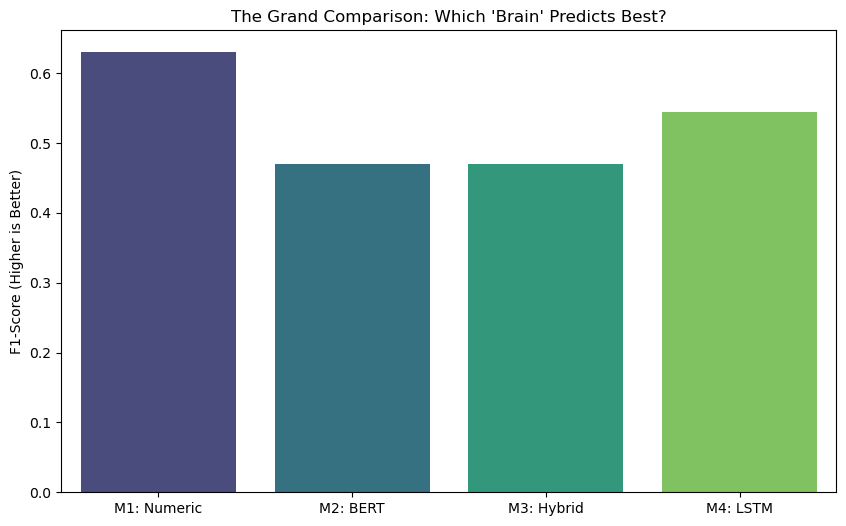

In [ ]:
# Final Comparison Chart 
plt.figure(figsize=(10, 6))
methods = ['M1: Numeric', 'M2: BERT', 'M3: Hybrid', 'M4: LSTM']
scores = [m1_f1, m2_f1, m3_f1, m4_f1]
sns.barplot(x=methods, y=scores, palette="viridis")
plt.title("The Grand Comparison: Which 'Brain' Predicts Best?")
plt.ylabel("F1-Score (Higher is Better)")
plt.show()